# 01c — Modelos de Embeddings

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Adamychen/m10_quarto/blob/main/notebooks/bloque1/01c-embeddings.ipynb)

> Este tema forma parte del **Bloque 1 — Fundamentos**. Se recomienda
> haber visto [01b-llms.qmd](01b-llms.qmd) primero.

> Este tema profundiza en la línea histórica presentada en el [panorama
> del Bloque 1](00-panorama.qmd). Allí se introducen one-hot, TF-IDF,
> word2vec, representaciones contextuales y SBERT; aquí se estudian sus
> mecanismos, modelos actuales y consecuencias geométricas.

In [1]:
!pip install -q sentence-transformers matplotlib scikit-learn

In [2]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 100
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.

## 0. Qué significa «embedding» en este bloque

La palabra *embedding* se utiliza para varias piezas relacionadas, pero
no idénticas. En todos los casos se trata de representar un objeto
mediante un vector aprendido o calculado. Lo que cambia es el objeto
representado, el momento del pipeline y el objetivo con el que se
entrenó el vector.

| Tipo de representación | Entrada | Depende del contexto | Uso típico |
|-----------------|-----------------|---------------------:|-----------------|
| **Embedding de token** | ID de una unidad del vocabulario | No, al inicio del modelo | Entrada de un Transformer |
| **Estado oculto contextual** | Secuencia de tokens procesada | Sí | Clasificación, generación, extracción |
| **Embedding de palabra estático** | Palabra del vocabulario | No | Similitud léxica y transferencia |
| **Embedding de frase** | Frase o consulta completa | Sí, mediante el encoder | Búsqueda semántica |
| **Embedding de documento** | Documento o chunk | Sí, según el modelo y el pooling | Indexación y RAG |

Por tanto, no todo vector producido por un modelo es automáticamente un
buen embedding para búsqueda. Un estado oculto puede contener
información útil para predecir el siguiente token, pero necesitar una
transformación o un entrenamiento adicional para que las distancias
entre frases sean interpretables.

> **Tres conceptos que no conviene confundir**
>
> 1.  La tabla de embeddings convierte IDs en vectores al comienzo del
>     Transformer.
> 2.  Las capas Transformer convierten esos vectores en estados ocultos
>     que incorporan contexto.
> 3.  Un modelo como SBERT o E5 se entrena específicamente para que la
>     distancia entre vectores de frases tenga utilidad para similitud y
>     recuperación.
>
> El [tema 01a](01a-transformer.qmd#sec-vistazo-transformer) muestra el
> recorrido interno, y [01e - Del estado oculto a la
> salida](01e-llm-por-dentro.qmd) explica cómo distintas cabezas pueden
> leer esos estados.

## Modelos de Embeddings

### De word2vec a sentence embeddings

La evolución de la representación vectorial del lenguaje:

<figure id="fig-timeline-embeddings">
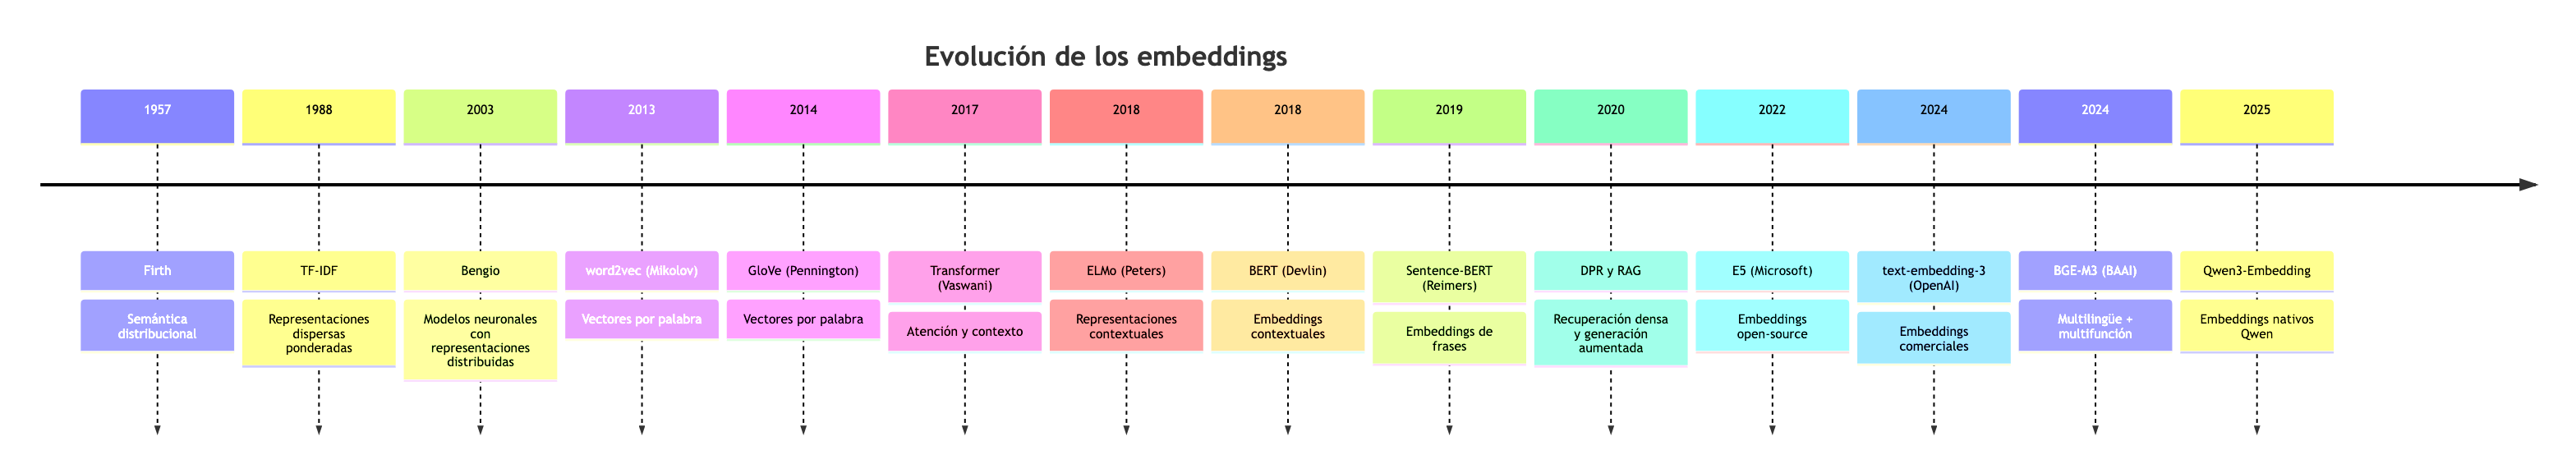
<figcaption>Figure 1</figcaption>
</figure>

La cronología debe leerse como una sucesión de problemas y soluciones,
no como una competición en la que cada modelo elimina por completo al
anterior:

| Etapa | Problema dominante | Idea aportada | Limitación que permanece |
|------------------|------------------|------------------|------------------|
| One-hot y BoW | El texto no es numérico | Asignar coordenadas y contar palabras | No hay semántica ni contexto |
| TF-IDF | No todas las palabras son igual de informativas | Ponderar términos según su rareza | La similitud sigue siendo léxica |
| Word2vec y GloVe | Las palabras relacionadas aparecen en contextos parecidos | Aprender vectores densos | Un vector fijo por palabra |
| ELMo y BERT | El significado depende de la frase | Representaciones contextuales | No toda salida es adecuada para recuperación |
| SBERT y E5 | Hay que comparar frases y consultas eficientemente | Objetivos contrastivos y espacio compartido | La calidad depende del dominio y los datos |
| Vector DB y RAG | Hay demasiados vectores para comparar uno a uno | Índices ANN y recuperación aumentada | La recuperación puede fallar y debe evaluarse |

Las referencias originales de esta evolución se encuentran en Firth
(1957), Salton & Buckley (1988), Bengio et al. (2003), Mikolov et al.
(2013), Pennington et al. (2014), Peters et al. (2018), Vaswani et al.
(2017), Devlin et al. (2019), Reimers & Gurevych (2019), Karpukhin et
al. (2020) y Wang et al. (2022).

> **Idioma de los textos de ejemplo**
>
> Los modelos de embeddings que usamos en este bloque
> (`all-MiniLM-L6-v2`) están entrenados principalmente en **inglés**.
> Por eso los ejemplos de código utilizan texto en inglés. Cada modelo
> lleva asociado un **tokenizador** entrenado en su idioma: usar un
> tokenizador inglés sobre texto español produce más subtokens por
> palabra y embeddings de menor calidad, porque el espacio semántico
> aprendido está calibrado para relaciones del inglés.
>
> Si necesitas trabajar con español, usa modelos multilingües como
> `intfloat/multilingual-e5-small` o `BAAI/bge-m3`. La API es la misma;
> solo cambia el nombre del modelo.

### Del embedding estático al embedding contextual

En un embedding estático, cada palabra tiene una única posición
aprendida. En una representación contextual, la posición depende de los
tokens que aparecen alrededor. Esta diferencia permite representar usos
distintos de una misma forma ortográfica:

``` text
El banco aprobó la hipoteca.
El banco estaba junto al río.
```

Un encoder contextual puede producir estados distintos para `banco` en
cada frase. Esa capacidad no significa que el modelo haya construido una
definición explícita en lenguaje natural. Significa que las capas han
transformado la representación teniendo en cuenta las relaciones con el
resto de la secuencia.

El paso desde estados por token a un único vector de frase exige además
una operación de agregación. Las estrategias habituales incluyen:

- **Mean pooling:** promediar los estados de los tokens válidos.
- **CLS pooling:** utilizar el estado de un token especial, cuando el
  modelo lo ha entrenado para ello.
- **Pooling aprendido:** combinar los estados mediante una capa
  entrenable.
- **Representación contrastiva:** entrenar el encoder para que pares
  relevantes queden próximos y pares no relevantes queden separados.

La elección del pooling y del objetivo de entrenamiento puede cambiar
sustancialmente la calidad de la búsqueda, incluso cuando el backbone
Transformer es el mismo.

### Semántica distribucional

El principio fundamental: **“You shall know a word by the company it
keeps”** (Firth (1957)). Palabras con contextos similares tienen
significados similares, y por tanto vectores cercanos en el espacio
semántico.

In [3]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

frases = [
    "A cat plays in the garden",
    "A feline chases a butterfly",
    "The dog sleeps on the rug",
    "Tomorrow will be a sunny day"
]

embeddings = model.encode(frases)
print(f"Forma de los embeddings: {embeddings.shape}")
print(f"Dimensión: {embeddings.shape[1]}")
print(f"Número de frases: {embeddings.shape[0]}")

Forma de los embeddings: (4, 384)
Dimensión: 384
Número de frases: 4

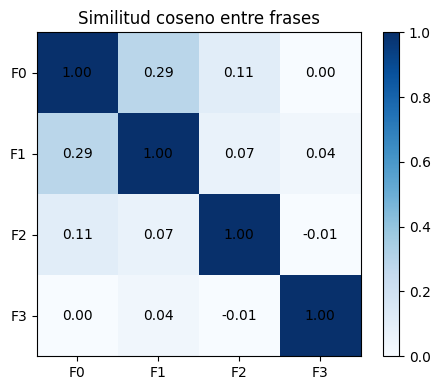

Notice how animal-related phrases (0, 1) have high similarity
while the weather phrase (3) is different from the rest.

In [4]:
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(embeddings)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(sim_matrix, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(frases)))
ax.set_yticks(range(len(frases)))
ax.set_xticklabels([f"F{i}" for i in range(len(frases))])
ax.set_yticklabels([f"F{i}" for i in range(len(frases))])
ax.set_title("Similitud coseno entre frases")

for i in range(len(frases)):
    for j in range(len(frases)):
        ax.text(j, i, f"{sim_matrix[i, j]:.2f}", ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print("Notice how animal-related phrases (0, 1) have high similarity")
print("while the weather phrase (3) is different from the rest.")

### Sentence-BERT

Sentence-BERT (SBERT) modifica BERT con una arquitectura **siamese** que
permite generar embeddings de frases comparables directamente. Usa
funciones de pérdida contrastiva (triplet loss, cosine similarity loss)
para que frases semánticamente cercanas tengan vectores cercanos.

<figure id="fig-sbert-arch">
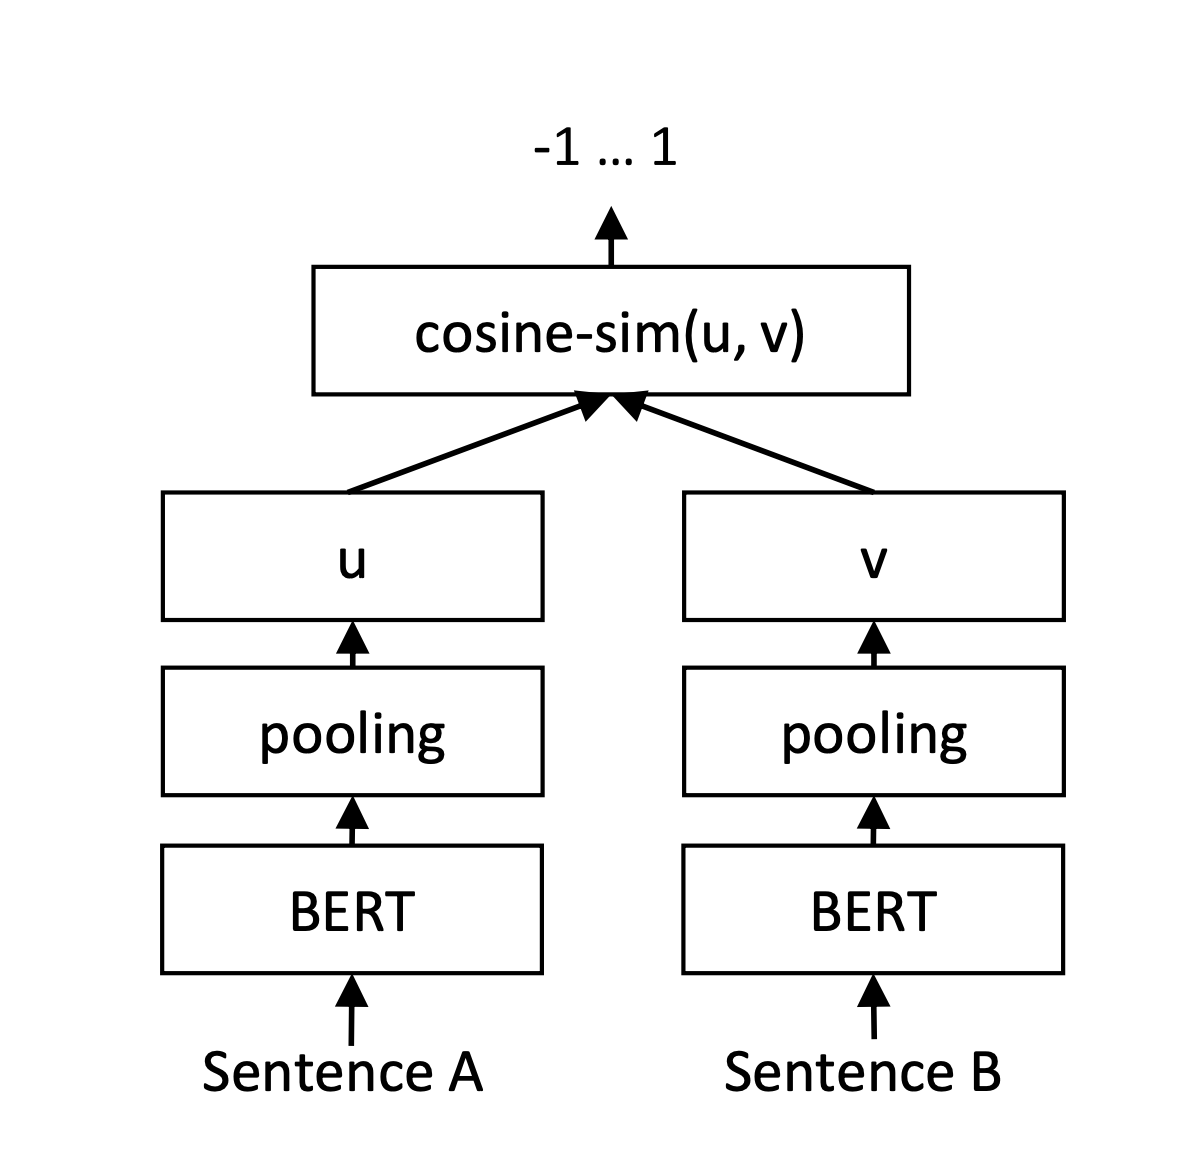
<figcaption>Figure 2: Arquitectura siamese de SBERT para
inferencia.</figcaption>
</figure>

### Comparativa de modelos de embeddings

| Modelo | Dimensiones | Tamaño | Uso |
|------------------|------------------|------------------|------------------|
| `all-MiniLM-L6-v2` | 384 | ~80 MB | Prototipado rápido |
| `intfloat/e5-small-v2` | 384 | ~120 MB | Propósito general open-source |
| `intfloat/e5-base-v2` | 768 | ~440 MB | Mayor precisión |
| `qwen3-embedding:0.6b` | 768 | ~640 MB | Embeddings nativos Qwen (disponible en Llamus) |
| `nomic-embed-text-v2-moe` | 768 | ~475 MB | Alta precisión, MoE eficiente |
| `mxbai-embed-large:v1` | 1024 | ~334 MB | Embeddings densos generales |
| `text-embedding-3-small` | 512 o 1536 | API | Comercial (OpenAI) |
| `text-embedding-3-large` | 256 o 3072 | API | Alta precisión (OpenAI) |

Table 1: Comparativa de modelos de embeddings por dimensiones, tamaño y
caso de uso

### Embeddings multimodales y tabulares

- **Multimodales (CLIP):** proyectan texto e imágenes en un mismo
  espacio vectorial, permitiendo búsqueda cross-modal (ej. “un perro
  jugando en la nieve” → imágenes correspondientes).
- **Tabulares (TabNet, SCARF):** generan embeddings de filas de datos
  tabulares usando atención, útiles para búsqueda semántica sobre datos
  estructurados (ej. encontrar clientes similares por perfil de compra).

## ¿Cuándo usar cada uno?

    - **Texto:** Sentence-BERT / E5 → **Vector DB**
    - **Texto + imágenes:** CLIP → **Búsqueda multimodal**
    - **Datos tabulares:** TabNet / SCARF → **Búsqueda por perfil**
    - **Código:** CodeBERT / GraphCodeBERT → **Búsqueda semántica de código**

### La geometría del espacio semántico

La intuición central de los embeddings es que **la proximidad vectorial
codifica proximidad semántica**. En un espacio bien entrenado:

- Conceptos similares caen **cerca** (rey, reina, príncipe).
- Conceptos distintos caen **lejos** (rey, bicicleta, GPU).
- Las **relaciones** entre conceptos se pueden capturar con **aritmética
  vectorial**:
  $\vec{\text{king}} - \vec{\text{man}} + \vec{\text{woman}} \approx \vec{\text{queen}}$.

<figure id="fig-embedding-space-2d">
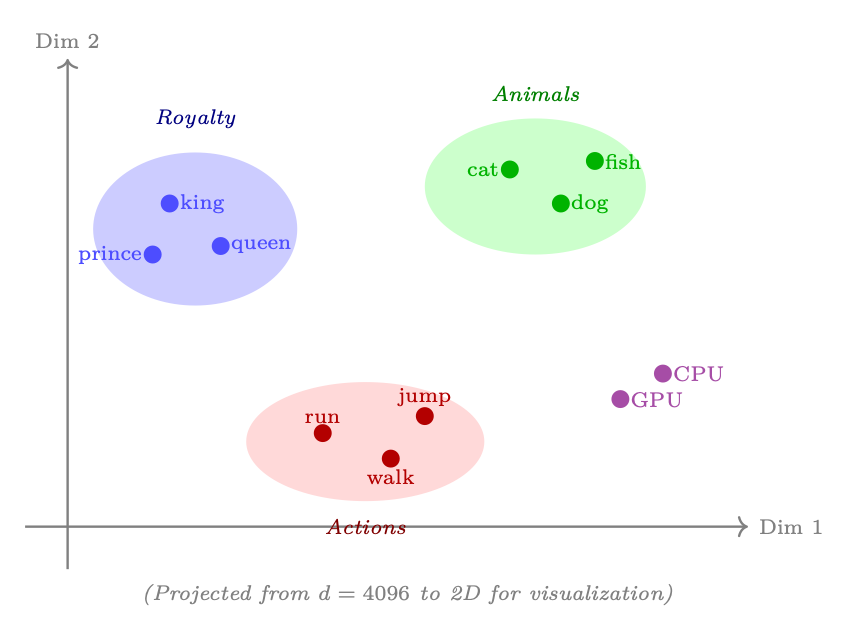
<figcaption>Figure 3: Proyección 2D de un espacio de embeddings: los
clusters por significado (royalty, animals, actions, tech) emergen de
los patrones de co-ocurrencia en el corpus de entrenamiento. Adaptada de
<span class="citation" data-cites="roitman2026hitchhiker">Roitman
(2026)</span>, Figure 6 (CC BY-SA 4.0).</figcaption>
</figure>

<figure id="fig-analogia-vectorial">
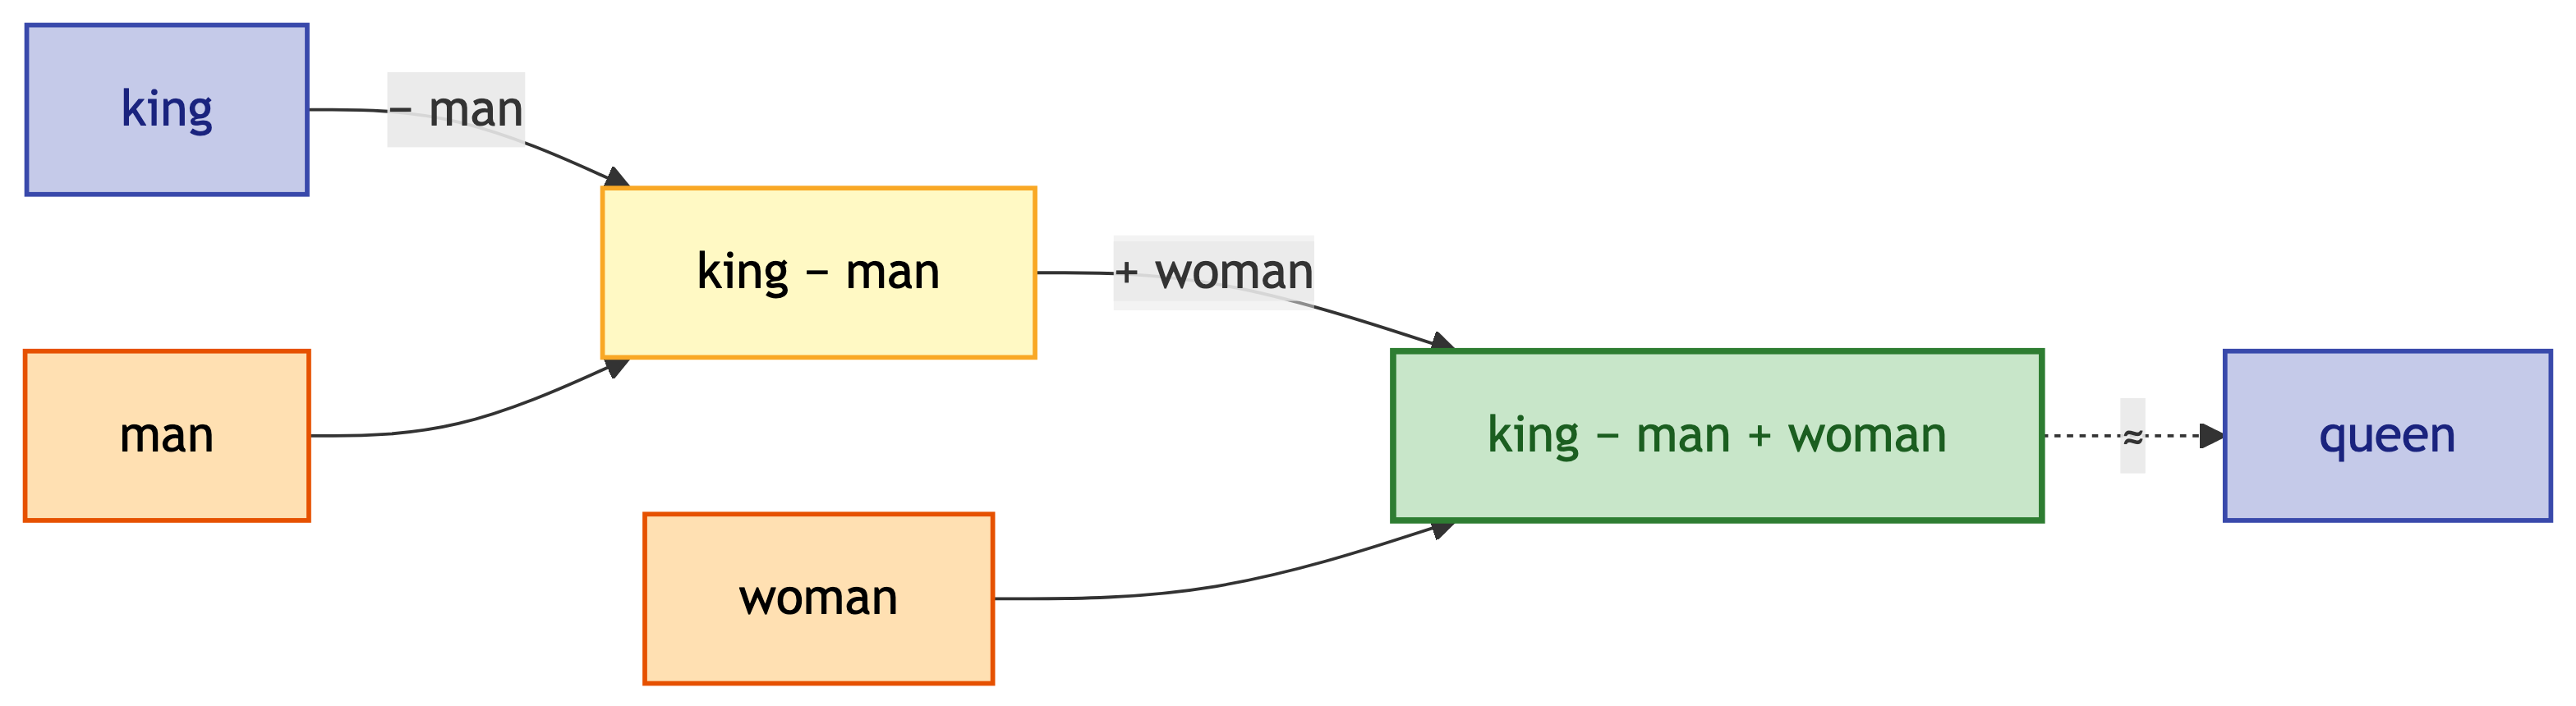
<figcaption>Figure 4</figcaption>
</figure>

> **Lectura de la imagen y el diagrama**
>
> La imagen proyecta 4096 dimensiones del espacio de embeddings en un
> plano 2D —pierde información exacta— pero conserva la **estructura por
> clusters**: las palabras se agrupan por tema, no por sintaxis. El
> diagrama Mermaid ilustra la **analogía vectorial**: el vector
> `king − man + woman` aterriza cerca de `queen`, porque la dirección
> `man → woman` (género) se suma a la dirección de `royalty` implícita
> en `king`. Esta es la propiedad que un sistema RAG explota cuando
> busca el documento “más similar” a una consulta.

------------------------------------------------------------------------

> Continúa con **[01d-vectordb.qmd](01d-vectordb.qmd)** — Bases de datos
> vectoriales.

# References

Bengio, Y., Ducharme, R., Vincent, P., & Jauvin, C. (2003). A neural
probabilistic language model. *Journal of Machine Learning Research*,
*3*, 1137–1155. <https://www.jmlr.org/papers/v3/bengio03a.html>

Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). BERT:
Pre-training of deep bidirectional transformers for language
understanding. *Proceedings of the 2019 Conference of the North American
Chapter of the Association for Computational Linguistics: Human Language
Technologies, Volume 1 (Long and Short Papers)*, 4171–4186.
<https://doi.org/10.18653/v1/N19-1423>

Firth, J. R. (1957). *A synopsis of linguistic theory, 1930–1955*.
Studies in Linguistic Analysis (Special Volume of the Philological
Society).

Karpukhin, V., Oguz, B., Min, S., Lewis, P., Wu, L., Edunov, S., Chen,
D., & Yih, W. (2020). Dense passage retrieval for open-domain question
answering. *Proceedings of the 2020 Conference on Empirical Methods in
Natural Language Processing (EMNLP)*, 6769–6781.
<https://doi.org/10.18653/v1/2020.emnlp-main.550>

Mikolov, T., Chen, K., Corrado, G., & Dean, J. (2013). Efficient
estimation of word representations in vector space. *arXiv Preprint
arXiv:1301.3781*. <https://arxiv.org/abs/1301.3781>

Pennington, J., Socher, R., & Manning, C. D. (2014). GloVe: Global
vectors for word representation. *Proceedings of the 2014 Conference on
Empirical Methods in Natural Language Processing (EMNLP)*, 1532–1543.
<https://doi.org/10.3115/v1/D14-1162>

Peters, M. E., Neumann, M., Iyyer, M., Gardner, M., Clark, C., Lee, K.,
& Zettlemoyer, L. (2018). Deep contextualized word representations.
*Proceedings of the 2018 Conference of the North American Chapter of the
Association for Computational Linguistics: Human Language Technologies,
Volume 1 (Long Papers)*, 2227–2237.
<https://doi.org/10.18653/v1/N18-1202>

Reimers, N., & Gurevych, I. (2019). Sentence-BERT: Sentence embeddings
using siamese BERT-networks. *Proceedings of the 2019 Conference on
Empirical Methods in Natural Language Processing and the 9th
International Joint Conference on Natural Language Processing
(EMNLP-IJCNLP)*, 3982–3992. <https://doi.org/10.18653/v1/D19-1410>

Roitman, H. (2026). *The hitchhiker’s guide to agentic AI: From
foundations to systems*. Versión 1.2.2. Licencia CC BY-SA 4.0.
<https://creativecommons.org/licenses/by-sa/4.0/>

Salton, G., & Buckley, C. (1988). Term-weighting approaches in automatic
text retrieval. *Information Processing and Management*, *24*(5),
513–523. <https://doi.org/10.1016/0306-4573(88)90021-0>

Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez,
A. N., Kaiser, L., & Polosukhin, I. (2017). *Attention is all you need*.
*30*. <https://arxiv.org/abs/1706.03762>

Wang, L., Yang, N., Huang, X., Jiao, B., Yang, L., Jiang, D., Majumder,
R., & Wei, F. (2022). Text embeddings by weakly-supervised contrastive
pre-training (E5). *arXiv Preprint arXiv:2212.03533*.
<https://arxiv.org/abs/2212.03533>